# Semana 1 — Repaso de probabilidad y cadenas de Markov en Python

En este laboratorio usaremos Python para repasar algunas distribuciones de probabilidad y estudiar cadenas de Markov a tiempo discreto.

La sesión tiene dos partes:

- **Parte 1 — Repaso de distribuciones:** binomial, Poisson y exponencial con `scipy.stats`.
- **Parte 2 — Cadenas de Markov:** representación matricial con NumPy y verificación de resultados con `jmarkov`.

### Qué se espera de ti

El curso supone que ya conoces variables, condicionales y ciclos básicos de Python. **No se supone que ya domines NumPy, SciPy, Matplotlib o `jmarkov`**: las instrucciones nuevas se introducirán paso a paso.

A lo largo del cuaderno encontrarás tres tipos de celdas:

- **Código central:** debes seguir la lógica y relacionarla con las ecuaciones.
- **Código proporcionado:** debes ejecutarlo e interpretar el resultado; no es necesario dominar todos sus detalles todavía.
- **Preguntas de interpretación:** son tan importantes como obtener el resultado numérico.

---
## Antes de comenzar

1. Ejecuta las celdas **de arriba hacia abajo**.
2. Si obtienes resultados extraños, reinicia el kernel y selecciona **Run All / Ejecutar todo**.
3. La instalación de `jmarkov` solo debe hacerse una vez por entorno. Si ya está instalado, aparecerá un mensaje indicando que el requisito está satisfecho.
4. Un error de Python no significa que el modelo esté mal. Lee la última línea del mensaje: normalmente allí aparece la causa más útil.

> **Importante:** Jupyter conserva en memoria las variables creadas en celdas anteriores. Por eso, ejecutar las celdas en desorden puede producir errores o resultados inconsistentes.

### Instalación de `jmarkov`

Ejecuta la siguiente celda antes de importar la librería.

In [1]:
!pip install jmarkov

Defaulting to user installation because normal site-packages is not writeable


### Importaciones

Estas líneas cargan las herramientas que usaremos. No es necesario memorizar los nombres hoy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import binom, poisson, expon
from jmarkov.dtmc import dtmc

---
## Parte 1 — Repaso de distribuciones de probabilidad

### Funciones clave de `scipy.stats`

| Función | Devuelve |
|:---|:---|
| `binom.pmf(k, n, p)` | $P(X=k)$ para una binomial |
| `binom.cdf(k, n, p)` | $P(X\leq k)$ para una binomial |
| `binom.sf(k, n, p)` | $P(X>k)$ para una binomial |
| `poisson.pmf(k, mu)` | $P(X=k)$ para una Poisson |
| `poisson.cdf(k, mu)` | $P(X\leq k)$ para una Poisson |
| `poisson.sf(k, mu)` | $P(X>k)$ para una Poisson |
| `expon.cdf(t, scale)` | $P(T\leq t)$ para una exponencial |
| `expon.sf(t, scale)` | $P(T>t)$ para una exponencial |
| `expon.ppf(q, scale)` | Cuantil $t$ tal que $P(T\leq t)=q$ |

> En `scipy.stats`, la distribución exponencial recibe `scale`, que corresponde a la media $\mu=1/\lambda$, no a la tasa $\lambda$.

### Problema 1 — Línea de producción: distribución binomial

Una línea produce **15 componentes por turno**. Cada componente es defectuoso con probabilidad $p=0.12$, independientemente de los demás.

Sea $X$ el número de componentes defectuosos:

$$X\sim\operatorname{Bin}(15,0.12).$$

Calcula:

1. $P(X=2)$.
2. $P(X\leq3)$.
3. $P(X\geq1)$.
4. La media y la desviación estándar.

In [3]:
numero_componentes = 15
probabilidad_defecto = 0.12

# 1. Probabilidad de exactamente 2 defectuosos
prob_exactamente_2 = binom.pmf(2, numero_componentes, probabilidad_defecto)

# 2. Probabilidad de a lo más 3 defectuosos
prob_a_lo_mas_3 = binom.cdf(3, numero_componentes, probabilidad_defecto)

# 3. Probabilidad de al menos 1 defectuoso
# Primero calculamos P(X = 0) y usamos el complemento.
prob_al_menos_1 = 1 - binom.pmf(0, numero_componentes, probabilidad_defecto)

# 4. Media y desviación estándar
media_defectuosos = numero_componentes * probabilidad_defecto
desviacion_defectuosos = (
    numero_componentes
    * probabilidad_defecto
    * (1 - probabilidad_defecto)
) ** 0.5

print("P(X = 2):", round(prob_exactamente_2, 4))
print("P(X <= 3):", round(prob_a_lo_mas_3, 4))
print("P(X >= 1):", round(prob_al_menos_1, 4))
print("Media:", round(media_defectuosos, 2))
print("Desviación estándar:", round(desviacion_defectuosos, 4))

P(X = 2): 0.287
P(X <= 3): 0.9041
P(X >= 1): 0.853
Media: 1.8
Desviación estándar: 1.2586


> ### 🎨 Visualización proporcionada
> La siguiente celda **no hace parte de los contenidos de programación evaluados en esta sesión**. Ejecútala y observa la gráfica. No es necesario comprender todos los comandos de Matplotlib en este momento.

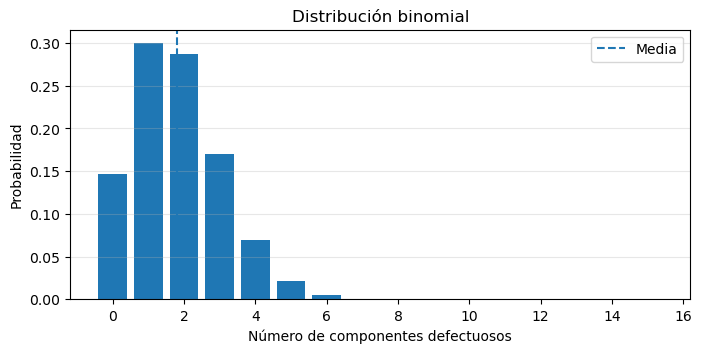

In [4]:
# CÓDIGO DE VISUALIZACIÓN PROPORCIONADO
valores_k = np.arange(0, numero_componentes + 1)
probabilidades_binomiales = binom.pmf(
    valores_k,
    numero_componentes,
    probabilidad_defecto
)

plt.figure(figsize=(8, 3.5))
plt.bar(valores_k, probabilidades_binomiales)
plt.axvline(media_defectuosos, linestyle="--", label="Media")
plt.xlabel("Número de componentes defectuosos")
plt.ylabel("Probabilidad")
plt.title("Distribución binomial")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

---
### Problema 2 — Centro de soporte técnico: distribución Poisson

Las solicitudes llegan a razón de $\lambda=4$ por hora.

Sea $X$ el número de solicitudes recibidas en una hora:

$$X\sim\operatorname{Poisson}(4).$$

Calcula:

1. $P(X=6)$.
2. $P(X<3)$.
3. $P(X>5)$.
4. La media y la varianza.
5. En media hora, el número esperado de solicitudes y la probabilidad de no recibir ninguna.

In [5]:
tasa_solicitudes = 4

prob_exactamente_6 = poisson.pmf(6, tasa_solicitudes)
prob_menos_de_3 = poisson.cdf(2, tasa_solicitudes)

# P(X > 5) puede calcularse con la función de supervivencia sf.
prob_mas_de_5 = poisson.sf(5, tasa_solicitudes)

media_solicitudes = tasa_solicitudes
varianza_solicitudes = tasa_solicitudes

tasa_media_hora = tasa_solicitudes * 0.5
prob_cero_media_hora = poisson.pmf(0, tasa_media_hora)

print("P(X = 6):", round(prob_exactamente_6, 4))
print("P(X < 3):", round(prob_menos_de_3, 4))
print("P(X > 5):", round(prob_mas_de_5, 4))
print("Media:", media_solicitudes)
print("Varianza:", varianza_solicitudes)
print("Solicitudes esperadas en media hora:", tasa_media_hora)
print("P(X = 0 en media hora):", round(prob_cero_media_hora, 4))

P(X = 6): 0.1042
P(X < 3): 0.2381
P(X > 5): 0.2149
Media: 4
Varianza: 4
Solicitudes esperadas en media hora: 2.0
P(X = 0 en media hora): 0.1353


> ### 🎨 Visualización proporcionada
> Ejecuta la celda e interpreta la forma de la distribución. Los comandos empleados para construir la gráfica no se evaluarán en esta sesión.

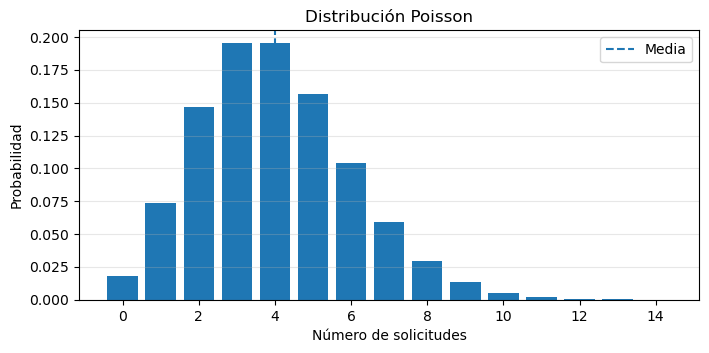

In [6]:
# CÓDIGO DE VISUALIZACIÓN PROPORCIONADO
valores_k_poisson = np.arange(0, 15)
probabilidades_poisson = poisson.pmf(valores_k_poisson, tasa_solicitudes)

plt.figure(figsize=(8, 3.5))
plt.bar(valores_k_poisson, probabilidades_poisson)
plt.axvline(tasa_solicitudes, linestyle="--", label="Media")
plt.xlabel("Número de solicitudes")
plt.ylabel("Probabilidad")
plt.title("Distribución Poisson")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

---
### Problema 3 — Vida útil de una bomba: distribución exponencial

El tiempo de vida $T$, medido en meses, sigue una distribución exponencial con media $\mu=6$ meses:

$$T\sim\operatorname{Exp}\left(\lambda=\frac{1}{6}\right).$$

Calcula:

1. $P(T>8)$.
2. $P(T<4)$.
3. $P(3<T<9)$.
4. La mediana.
5. El tiempo $t$ para el cual el 90 % de las bombas todavía no ha fallado: $P(T>t)=0.90$.

In [7]:
media_vida = 6

prob_mas_de_8 = expon.sf(8, scale=media_vida)
prob_menos_de_4 = expon.cdf(4, scale=media_vida)
prob_entre_3_y_9 = (
    expon.cdf(9, scale=media_vida)
    - expon.cdf(3, scale=media_vida)
)

mediana_vida = expon.ppf(0.50, scale=media_vida)

# P(T > t) = 0.90 equivale a P(T <= t) = 0.10.
tiempo_supervivencia_90 = expon.ppf(0.10, scale=media_vida)

print("P(T > 8):", round(prob_mas_de_8, 4))
print("P(T < 4):", round(prob_menos_de_4, 4))
print("P(3 < T < 9):", round(prob_entre_3_y_9, 4))
print("Mediana:", round(mediana_vida, 4), "meses")
print(
    "Tiempo para conservar 90 % sin fallar:",
    round(tiempo_supervivencia_90, 4),
    "meses"
)

P(T > 8): 0.2636
P(T < 4): 0.4866
P(3 < T < 9): 0.3834
Mediana: 4.1589 meses
Tiempo para conservar 90 % sin fallar: 0.6322 meses


> ### 🎨 Visualización proporcionada
> Esta celda sombrea el área correspondiente a $P(T>8)$. Su propósito es apoyar la interpretación probabilística; no debes aprender todavía todos los comandos gráficos.

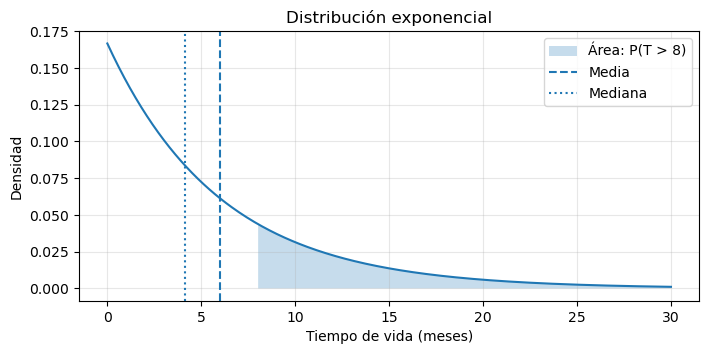

In [8]:
# CÓDIGO DE VISUALIZACIÓN PROPORCIONADO
tiempos = np.linspace(0, 30, 300)
densidad = expon.pdf(tiempos, scale=media_vida)

plt.figure(figsize=(8, 3.5))
plt.plot(tiempos, densidad)
plt.fill_between(
    tiempos,
    densidad,
    where=(tiempos > 8),
    alpha=0.25,
    label="Área: P(T > 8)"
)
plt.axvline(media_vida, linestyle="--", label="Media")
plt.axvline(mediana_vida, linestyle=":", label="Mediana")
plt.xlabel("Tiempo de vida (meses)")
plt.ylabel("Densidad")
plt.title("Distribución exponencial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Parte 2 — Cadenas de Markov a tiempo discreto

Antes de construir una cadena, revisaremos cuatro operaciones de NumPy que utilizaremos:

1. Crear un vector.
2. Crear una matriz.
3. Consultar una entrada o una fila.
4. Multiplicar un vector fila por una matriz con `@`.

> Un arreglo de NumPy se parece a una lista, pero permite realizar operaciones numéricas y matriciales de manera directa.

In [9]:
# Vector de tres posiciones
vector_ejemplo = np.array([1.0, 0.0, 0.0])

# Matriz de tres filas y tres columnas
matriz_ejemplo = np.array([
    [0.60, 0.30, 0.10],
    [0.20, 0.50, 0.30],
    [0.10, 0.30, 0.60]
])

print("Vector:", vector_ejemplo)
print("Entrada de la fila 0, columna 1:", matriz_ejemplo[0, 1])
print("Primera fila:", matriz_ejemplo[0, :])
print("Suma de la primera fila:", matriz_ejemplo[0, :].sum())

Vector: [1. 0. 0.]
Entrada de la fila 0, columna 1: 0.3
Primera fila: [0.6 0.3 0.1]
Suma de la primera fila: 0.9999999999999999


### El operador `@`

En este laboratorio, las distribuciones de probabilidad se representan como **vectores fila**. Si $\pi(0)$ es la distribución inicial y $P$ es la matriz de transición, entonces:

$$\pi(1)=\pi(0)P.$$

En Python, el producto matricial se escribe con `@`:

```python
pi_1 = pi_0 @ P
```

`@` **no** multiplica componente por componente. Cada entrada del resultado se obtiene mediante una suma de productos.

In [10]:
resultado_ejemplo = vector_ejemplo @ matriz_ejemplo

print("Vector inicial:", vector_ejemplo)
print("Vector después de un paso:", resultado_ejemplo)

Vector inicial: [1. 0. 0.]
Vector después de un paso: [0.6 0.3 0.1]


### Notación del curso

| Símbolo | Significado |
|:---|:---|
| $X_n$ | Estado del sistema en el periodo $n$ |
| $\mathcal{S}$ | Espacio de estados |
| $P_{ij}=P(X_{n+1}=j\mid X_n=i)$ | Probabilidad de pasar de $i$ a $j$ |
| $\boldsymbol{\pi}(n)=\boldsymbol{\pi}(0)P^n$ | Distribución en el periodo $n$ |
| $\boldsymbol{\pi}$ | Distribución estacionaria: $\boldsymbol{\pi}P=\boldsymbol{\pi}$ |

Primero realizaremos las operaciones con NumPy. Después utilizaremos `jmarkov` para verificar los resultados.

---
### Ejercicio 1 — Régimen del mercado accionario

El estado diario del mercado se modela mediante:

$$\mathcal{S}=\{0=\text{Alcista},\;1=\text{Lateral},\;2=\text{Bajista}\}$$

$$
P=
\begin{pmatrix}
0.60&0.30&0.10\\
0.20&0.50&0.30\\
0.10&0.30&0.60
\end{pmatrix}.
$$

1. Representa $P$ como arreglo de NumPy y comprueba que cada fila suma 1.
2. Partiendo de un mercado bajista, calcula $\pi(n)$ para $n=1,\ldots,5$.
3. Calcula una aproximación de la distribución estacionaria.
4. Determina cuándo el cambio entre dos distribuciones consecutivas es menor que 0.001.
5. Verifica los resultados con `jmarkov`.

In [11]:
P_mercado = np.array([
    [0.60, 0.30, 0.10],
    [0.20, 0.50, 0.30],
    [0.10, 0.30, 0.60]
])

estados_mercado = ["Alcista", "Lateral", "Bajista"]

for indice_fila in range(len(estados_mercado)):
    suma_fila = (
        P_mercado[indice_fila, 0]
        + P_mercado[indice_fila, 1]
        + P_mercado[indice_fila, 2]
    )

    print(
        "Fila",
        estados_mercado[indice_fila],
        "- suma:",
        round(suma_fila, 2)
    )

Fila Alcista - suma: 1.0
Fila Lateral - suma: 1.0
Fila Bajista - suma: 1.0


### Un paso, término a término

Si el mercado comienza en estado bajista:

$$\pi(0)=[0,\;0,\;1].$$

Para calcular la entrada $j$ de $\pi(1)$ usamos:

$$\pi_j(1)=\sum_i\pi_i(0)P_{ij}.$$

El siguiente doble ciclo reproduce exactamente esa suma. Después comparamos con el operador `@`.

In [12]:
pi0_mercado = np.array([0.0, 0.0, 1.0])

pi1_mercado_manual = np.array([0.0, 0.0, 0.0])

for estado_destino in range(3):
    suma = 0.0

    for estado_origen in range(3):
        suma = (
            suma
            + pi0_mercado[estado_origen]
            * P_mercado[estado_origen, estado_destino]
        )

    pi1_mercado_manual[estado_destino] = suma

pi1_mercado_producto = pi0_mercado @ P_mercado

print("Resultado término a término:", pi1_mercado_manual)
print("Resultado con pi0 @ P:", pi1_mercado_producto)

Resultado término a término: [0.1 0.3 0.6]
Resultado con pi0 @ P: [0.1 0.3 0.6]


> **Comprueba:** ambos resultados deben ser iguales. A partir de ahora usaremos `@`, pues ya sabemos qué operación representa.

In [13]:
pi_mercado_actual = pi0_mercado.copy()

for dia in range(1, 6):
    pi_mercado_actual = pi_mercado_actual @ P_mercado

    print(
        "Día",
        dia,
        "- distribución:",
        np.round(pi_mercado_actual, 4)
    )

pi5_mercado_manual = pi_mercado_actual.copy()

print(
    "P(X_5 = Alcista | X_0 = Bajista):",
    round(pi5_mercado_manual[0], 4)
)

Día 1 - distribución: [0.1 0.3 0.6]
Día 2 - distribución: [0.18 0.36 0.46]
Día 3 - distribución: [0.226 0.372 0.402]
Día 4 - distribución: [0.2502 0.3744 0.3754]
Día 5 - distribución: [0.2625 0.3749 0.3626]
P(X_5 = Alcista | X_0 = Bajista): 0.2625


### Aproximación numérica de la distribución estacionaria

Repetiremos:

$$\pi_{\text{nueva}}=\pi_{\text{anterior}}P$$

hasta que el cambio máximo sea menor que:

$$0.000001=10^{-6}.$$

Primero escribiremos por separado las diferencias de cada componente. Así puede verse qué hace el criterio de parada.

In [14]:
pi_mercado_anterior = np.array([1/3, 1/3, 1/3])
tolerancia_estacionaria = 0.000001

for iteracion in range(1, 1000):
    pi_mercado_nueva = pi_mercado_anterior @ P_mercado

    diferencia_alcista = abs(
        pi_mercado_nueva[0] - pi_mercado_anterior[0]
    )
    diferencia_lateral = abs(
        pi_mercado_nueva[1] - pi_mercado_anterior[1]
    )
    diferencia_bajista = abs(
        pi_mercado_nueva[2] - pi_mercado_anterior[2]
    )

    cambio_maximo = max(
        diferencia_alcista,
        diferencia_lateral,
        diferencia_bajista
    )

    pi_mercado_anterior = pi_mercado_nueva

    if cambio_maximo < tolerancia_estacionaria:
        break

pi_mercado_estacionaria_manual = pi_mercado_anterior.copy()

print("Iteraciones:", iteracion)

for indice_estado in range(len(estados_mercado)):
    print(
        estados_mercado[indice_estado],
        ":",
        round(pi_mercado_estacionaria_manual[indice_estado], 4)
    )

Iteraciones: 16
Alcista : 0.275
Lateral : 0.375
Bajista : 0.35


La expresión compacta

```python
np.max(np.abs(pi_nueva - pi_anterior))
```

realiza las mismas operaciones: calcula las diferencias absolutas y selecciona la mayor. La usaremos más adelante, después de haber visto su significado.

In [15]:
pi_mercado_anterior = pi0_mercado.copy()
tolerancia_estabilizacion = 0.001

for dia in range(1, 200):
    pi_mercado_nueva = pi_mercado_anterior @ P_mercado

    cambio_maximo = np.max(
        np.abs(pi_mercado_nueva - pi_mercado_anterior)
    )

    pi_mercado_anterior = pi_mercado_nueva

    if cambio_maximo < tolerancia_estabilizacion:
        print("Criterio alcanzado en el día:", dia)
        break

Criterio alcanzado en el día: 9


> ### 🎨 Visualización proporcionada
> La siguiente celda organiza los resultados y los muestra en una gráfica. **No es necesario entender todos los comandos gráficos en la primera lectura.** Lo importante es identificar que las tres probabilidades se aproximan a valores estables.

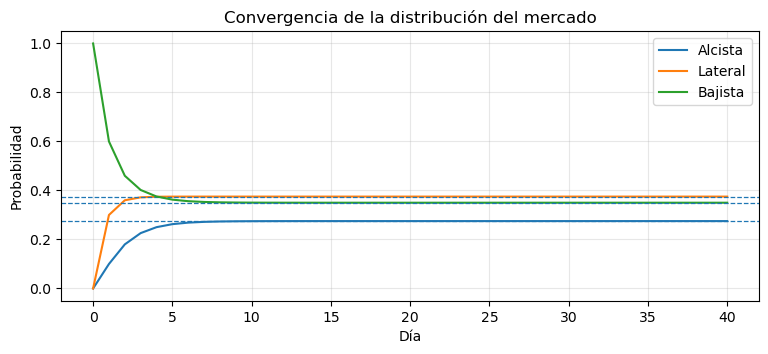

In [16]:
# CÓDIGO DE VISUALIZACIÓN PROPORCIONADO
numero_dias_grafica = 40
evolucion_mercado = np.zeros((numero_dias_grafica + 1, 3))

pi_para_grafica = pi0_mercado.copy()
evolucion_mercado[0, :] = pi_para_grafica

for dia in range(1, numero_dias_grafica + 1):
    pi_para_grafica = pi_para_grafica @ P_mercado
    evolucion_mercado[dia, :] = pi_para_grafica

plt.figure(figsize=(9, 3.5))

for indice_estado in range(3):
    plt.plot(
        evolucion_mercado[:, indice_estado],
        label=estados_mercado[indice_estado]
    )
    plt.axhline(
        pi_mercado_estacionaria_manual[indice_estado],
        linestyle="--",
        linewidth=0.9
    )

plt.xlabel("Día")
plt.ylabel("Probabilidad")
plt.title("Convergencia de la distribución del mercado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Verificación con `jmarkov`

`jmarkov` recibe la matriz de transición y ofrece métodos ya programados:

- `transient_probabilities(n, alpha)`: calcula la distribución después de $n$ transiciones.
- `steady_state()`: calcula una distribución estacionaria.
- `is_ergodic()`: comprueba si la cadena es irreducible y aperiódica.

No es necesario estudiar programación orientada a objetos en esta sesión. Lee, por ejemplo,

```python
mercado.steady_state()
```

como: “pedirle a la cadena `mercado` su distribución estacionaria”.

Matemáticamente, la distribución transitoria es:

$$\pi(n)=\pi(0)P^n.$$

En NumPy, si quisiéramos calcularla directamente, usaríamos:

```python
pi_n = pi_0 @ np.linalg.matrix_power(P, n)
```

`P**n` no representa la potencia matricial.

In [17]:
cadena_mercado = dtmc(
    P_mercado,
    states=np.array(estados_mercado)
)

pi5_mercado_jmarkov = cadena_mercado.transient_probabilities(
    n=5,
    alpha=pi0_mercado
)

pi_mercado_estacionaria_jmarkov = cadena_mercado.steady_state()

print("¿Es ergódica?:", cadena_mercado.is_ergodic())
print()
print("pi(5) con NumPy:", np.round(pi5_mercado_manual, 4))
print("pi(5) con jmarkov:", np.round(pi5_mercado_jmarkov, 4))
print()
print(
    "Estacionaria con NumPy:",
    np.round(pi_mercado_estacionaria_manual, 4)
)
print(
    "Estacionaria con jmarkov:",
    np.round(pi_mercado_estacionaria_jmarkov, 4)
)

¿Es ergódica?: True

pi(5) con NumPy: [0.2625 0.3749 0.3626]
pi(5) con jmarkov: [0.2625 0.3749 0.3626]

Estacionaria con NumPy: [0.275 0.375 0.35 ]
Estacionaria con jmarkov: [0.275 0.375 0.35 ]


---
### Ejercicio 2 — Inventario con política $(s,S)$

Una tienda utiliza la política $(s=2,S=6)$.

La secuencia dentro de cada día es:

1. Se observa el inventario $X_n$.
2. Si $X_n\leq2$, se repone inmediatamente hasta 6 unidades.
3. Ocurre la demanda diaria $D\sim\operatorname{Poisson}(2)$.
4. El inventario restante se convierte en $X_{n+1}$.

La demanda no atendida se pierde.

$$
X_{n+1}=\max(0,\widetilde X_n-D),
\qquad
\widetilde X_n=
\begin{cases}
6,&X_n\leq2,\\
X_n,&X_n>2.
\end{cases}
$$

El espacio de estados es:

$$\mathcal S=\{0,1,2,3,4,5,6\}.$$

En este laboratorio llamaremos *stockout* al evento $X_n=0$. Esto no es necesariamente igual a la probabilidad de perder ventas durante todo el día.

### Antes de programar toda la matriz: construyamos una fila

Supón que al comienzo del día hay 4 unidades. Como $4>s$, no se hace pedido. Entonces:

- Si $D=0$, el siguiente estado es 4.
- Si $D=1$, el siguiente estado es 3.
- Si $D=2$, el siguiente estado es 2.
- Si $D=3$, el siguiente estado es 1.
- Si $D\geq4$, el siguiente estado es 0.

La siguiente celda construye únicamente esa fila.

In [18]:
tasa_demanda = 2

fila_desde_4 = np.zeros(7)

fila_desde_4[4] = poisson.pmf(0, tasa_demanda)
fila_desde_4[3] = poisson.pmf(1, tasa_demanda)
fila_desde_4[2] = poisson.pmf(2, tasa_demanda)
fila_desde_4[1] = poisson.pmf(3, tasa_demanda)
fila_desde_4[0] = poisson.sf(3, tasa_demanda)

print("Fila de transición desde X_n = 4:")
print(np.round(fila_desde_4, 4))
print("Suma:", round(fila_desde_4.sum(), 4))

Fila de transición desde X_n = 4:
[0.1429 0.1804 0.2707 0.2707 0.1353 0.     0.    ]
Suma: 1.0


### Generalización a todos los estados

Ahora repetiremos la misma lógica para cada posible inventario inicial. La versión se escribe deliberadamente con `if` y `else` en varias líneas para que el flujo sea visible.

In [19]:
punto_reorden = 2
nivel_objetivo = 6
capacidad = 6

P_inventario = np.zeros((capacidad + 1, capacidad + 1))

for inventario_inicial in range(capacidad + 1):

    if inventario_inicial <= punto_reorden:
        inventario_disponible = nivel_objetivo
    else:
        inventario_disponible = inventario_inicial

    for inventario_siguiente in range(capacidad + 1):

        if inventario_siguiente >= 1:
            demanda_necesaria = (
                inventario_disponible
                - inventario_siguiente
            )

            P_inventario[
                inventario_inicial,
                inventario_siguiente
            ] = poisson.pmf(
                demanda_necesaria,
                tasa_demanda
            )

        else:
            P_inventario[
                inventario_inicial,
                inventario_siguiente
            ] = poisson.sf(
                inventario_disponible - 1,
                tasa_demanda
            )

for inventario_inicial in range(capacidad + 1):
    print(
        "Fila X =",
        inventario_inicial,
        "- suma:",
        round(P_inventario[inventario_inicial, :].sum(), 4)
    )

Fila X = 0 - suma: 1.0
Fila X = 1 - suma: 1.0
Fila X = 2 - suma: 1.0
Fila X = 3 - suma: 1.0
Fila X = 4 - suma: 1.0
Fila X = 5 - suma: 1.0
Fila X = 6 - suma: 1.0


> **Pregunta de interpretación:** ¿por qué las filas correspondientes a los estados 0, 1 y 2 son iguales?

In [20]:
pi0_inventario = np.zeros(capacidad + 1)
pi0_inventario[6] = 1.0

pi_inventario_actual = pi0_inventario.copy()

for dia in range(1, 4):
    pi_inventario_actual = (
        pi_inventario_actual @ P_inventario
    )

    print(
        "Distribución en el día",
        dia,
        ":",
        np.round(pi_inventario_actual, 4)
    )

pi3_inventario_manual = pi_inventario_actual.copy()

print(
    "P(X_3 = 0 | X_0 = 6):",
    round(pi3_inventario_manual[0], 4)
)

Distribución en el día 1 : [0.0166 0.0361 0.0902 0.1804 0.2707 0.2707 0.1353]
Distribución en el día 2 : [0.1159 0.1321 0.196  0.2211 0.1852 0.1119 0.0377]
Distribución en el día 3 : [0.1118 0.1208 0.1736 0.1973 0.1857 0.1455 0.0652]
P(X_3 = 0 | X_0 = 6): 0.1118


In [21]:
pi_inventario_anterior = (
    np.ones(capacidad + 1) / (capacidad + 1)
)

tolerancia_inventario = 0.00000001

for iteracion in range(1, 2000):
    pi_inventario_nueva = (
        pi_inventario_anterior @ P_inventario
    )

    cambio_maximo = np.max(
        np.abs(
            pi_inventario_nueva
            - pi_inventario_anterior
        )
    )

    pi_inventario_anterior = pi_inventario_nueva

    if cambio_maximo < tolerancia_inventario:
        break

pi_inventario_estacionaria_manual = (
    pi_inventario_anterior.copy()
)

inventario_promedio = 0.0

for nivel_inventario in range(capacidad + 1):
    inventario_promedio = (
        inventario_promedio
        + pi_inventario_estacionaria_manual[nivel_inventario]
        * nivel_inventario
    )

print("Iteraciones:", iteracion)
print(
    "P(stockout a largo plazo):",
    round(pi_inventario_estacionaria_manual[0], 4)
)
print(
    "Inventario promedio a largo plazo:",
    round(inventario_promedio, 3)
)

Iteraciones: 14
P(stockout a largo plazo): 0.1077
Inventario promedio a largo plazo: 2.934


### Verificación con `jmarkov`

Aquí estamos **evaluando una política dada**, no buscando todavía los mejores valores de $s$ y $S$.

In [22]:
estados_inventario = []

for nivel in range(capacidad + 1):
    estados_inventario.append("X=" + str(nivel))

cadena_inventario = dtmc(
    P_inventario,
    states=np.array(estados_inventario)
)

pi3_inventario_jmarkov = (
    cadena_inventario.transient_probabilities(
        n=3,
        alpha=pi0_inventario
    )
)

pi_inventario_estacionaria_jmarkov = (
    cadena_inventario.steady_state()
)

print(
    "pi(3) con NumPy:",
    np.round(pi3_inventario_manual, 4)
)
print(
    "pi(3) con jmarkov:",
    np.round(pi3_inventario_jmarkov, 4)
)
print()
print(
    "Estacionaria con NumPy:",
    np.round(pi_inventario_estacionaria_manual, 4)
)
print(
    "Estacionaria con jmarkov:",
    np.round(pi_inventario_estacionaria_jmarkov, 4)
)

pi(3) con NumPy: [0.1118 0.1208 0.1736 0.1973 0.1857 0.1455 0.0652]
pi(3) con jmarkov: [0.1118 0.1208 0.1736 0.1973 0.1857 0.1455 0.0652]

Estacionaria con NumPy: [0.1077 0.1187 0.174  0.2016 0.1903 0.145  0.0627]
Estacionaria con jmarkov: [0.1077 0.1187 0.174  0.2016 0.1903 0.145  0.0627]


---
## Ejercicio abierto — Degradación de un activo industrial

Una empresa observa semanalmente una máquina:

$$
\mathcal S=
\{0=\text{Nuevo},\;1=\text{Regular},\;2=\text{Deteriorado},\;3=\text{Falla}\}.
$$

$$
P=
\begin{pmatrix}
0.70&0.25&0.05&0.00\\
0.10&0.55&0.30&0.05\\
0.00&0.15&0.40&0.45\\
0.80&0.20&0.00&0.00
\end{pmatrix}.
$$

Cuando la máquina falla, se reemplaza de inmediato. Por eso, la fila del estado Falla permite pasar a Nuevo o Regular: **Falla no es un estado absorbente**.

Resuelve con `jmarkov`:

1. Verifica que la cadena es ergódica.
2. Calcula la distribución en la semana 4 partiendo de una máquina nueva.
3. Obtén la probabilidad de falla en la semana 4.
4. Calcula la fracción de semanas en estado Falla a largo plazo.
5. Grafica $P(X_n=\text{Falla}\mid X_0=\text{Nuevo})$ para $n=0,\ldots,30$.

### Uso responsable de IA

Puedes pedir ayuda a una herramienta de IA, pero no debes aceptar el código sin validarlo.

1. **Solicita el código** con un prompt preciso.
2. **Calcula primero un número de referencia** sin `jmarkov`.
3. **Ejecuta y compara.**
4. Si los valores no coinciden, revisa tanto tu cálculo como el código recibido.

Errores que debes vigilar:

- invertir la convención fila/columna;
- tratar Falla como estado absorbente;
- usar `P**n` como si fuera potencia matricial;
- modificar el orden de los estados;
- calcular una distribución estacionaria sin verificar las propiedades de la cadena.

#### Prompt sugerido

```text
Tengo una cadena de Markov a tiempo discreto en Python.

Convención:
P[i,j] = P(X_(n+1)=j | X_n=i).
Las distribuciones son vectores fila.

Estados:
0 = Nuevo
1 = Regular
2 = Deteriorado
3 = Falla

Matriz de transición:
[[0.70, 0.25, 0.05, 0.00],
 [0.10, 0.55, 0.30, 0.05],
 [0.00, 0.15, 0.40, 0.45],
 [0.80, 0.20, 0.00, 0.00]]

La máquina se reemplaza después de fallar; por eso Falla no es absorbente.

Usa:
from jmarkov.dtmc import dtmc

Métodos:
cadena.is_ergodic()
cadena.steady_state()
cadena.transient_probabilities(n, alpha)

Resuelve:
1. Verifica que la cadena es ergódica.
2. Calcula la distribución en la semana 4 desde una máquina nueva.
3. Reporta la probabilidad de Falla en la semana 4.
4. Reporta la probabilidad estacionaria de Falla.
5. Grafica la probabilidad de Falla entre las semanas 0 y 30.

Separa claramente el código de cálculo del código de visualización.
```

### Verificación manual

Usaremos una referencia de dos pasos, más informativa que copiar simplemente la primera fila de $P$:

$$
P(X_2=\text{Falla}\mid X_0=\text{Nuevo})
=
\sum_i P_{0i}P_{i3}.
$$

Calcula el valor término a término y compáralo después con la respuesta de la IA.

In [23]:
P_maquina = np.array([
    [0.70, 0.25, 0.05, 0.00],
    [0.10, 0.55, 0.30, 0.05],
    [0.00, 0.15, 0.40, 0.45],
    [0.80, 0.20, 0.00, 0.00]
])

estados_maquina = [
    "Nuevo",
    "Regular",
    "Deteriorado",
    "Falla"
]

for indice_fila in range(len(estados_maquina)):
    print(
        "Fila",
        estados_maquina[indice_fila],
        "- suma:",
        round(P_maquina[indice_fila, :].sum(), 2)
    )

prob_falla_semana_2_manual = 0.0

for estado_intermedio in range(4):
    prob_falla_semana_2_manual = (
        prob_falla_semana_2_manual
        + P_maquina[0, estado_intermedio]
        * P_maquina[estado_intermedio, 3]
    )

print()
print(
    "Referencia manual P(X_2 = Falla | X_0 = Nuevo):",
    round(prob_falla_semana_2_manual, 4)
)

Fila Nuevo - suma: 1.0
Fila Regular - suma: 1.0
Fila Deteriorado - suma: 1.0
Fila Falla - suma: 1.0

Referencia manual P(X_2 = Falla | X_0 = Nuevo): 0.035


In [ ]:
# Pega y adapta aquí el código producido con ayuda de IA.
#
# Antes de aceptarlo:
# 1. Comprueba que las filas de P sumen 1.
# 2. Comprueba que Falla no haya sido tratado como absorbente.
# 3. Compara P(X_2 = Falla | X_0 = Nuevo) con la referencia manual.
# 4. Interpreta los resultados con tus propias palabras.

---
## Lista de comprobación final

Antes de terminar, asegúrate de poder explicar:

- qué representa una fila de la matriz de transición;
- por qué cada fila debe sumar 1;
- qué representa el vector $\pi(n)$;
- qué operación realiza `pi @ P`;
- la diferencia entre una distribución transitoria y una estacionaria;
- por qué `jmarkov` se usa para verificar cálculos;
- por qué en el inventario estamos evaluando una política dada y no optimizándola;
- por qué el código de las gráficas puede ejecutarse sin dominarse todavía.

<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>